# Notebook 3: Cross-Repository Lane Comparison

**Goal:** Compare the general LLM and agentic lanes on shared outcomes.

**Inputs:** `evaluation_attempts.csv`, `evaluation_candidates.csv`, `evaluation_repositories.csv`

**RQs addressed:** RQ4, RQ6, RQ9

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.normalize import build_paired_comparison
from analysis.statistics import (
    mcnemar_test,
    wilcoxon_signed_rank,
    mann_whitney_u,
    bootstrap_ci,
    repository_blocked_bootstrap,
)
from analysis.plots import (
    paired_win_loss_matrix,
    metric_delta_distribution,
    cost_vs_improvement_scatter,
)

sns.set_theme(style='whitegrid')

DATA_DIR   = Path('../data')
REQUIRED_FILES = ['evaluation_attempts.csv', 'evaluation_candidates.csv']
missing = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing required analysis CSVs in {DATA_DIR}: {missing}')
attempts   = pd.read_csv(DATA_DIR / 'evaluation_attempts.csv')
candidates = pd.read_csv(DATA_DIR / 'evaluation_candidates.csv')
repos      = pd.read_csv(DATA_DIR / 'evaluation_repositories.csv') if (DATA_DIR / 'evaluation_repositories.csv').exists() else pd.DataFrame()

## 1. Shared Outcome Definitions

Both lanes are compared on the same outcome measures to ensure comparability.

- `validated_success` â€” test passed validation (VEP *or* VLI); use as the broad success signal
- `validated_evidence_positive` â€” test passed **and** metrics improved â‰¥ noise floor (VEP only); use as the primary practical-impact signal
- `coverage_delta` â€” line coverage change at attempt level
- `mutation_score_delta` â€” mutation score change at attempt level
- `duration_seconds` â€” wall-clock runtime

Lane-specific metrics (Roslyn diagnostics, repair counts, run_status) are **not** compared across lanes.

> **Note on units.** Coverage is stored as a 0â€“1 fraction; a delta of 0.01 = 1 percentage point.
> Mutation score is stored as 0â€“100; a delta of 1.0 = 1 percentage point.
> The `metric_improved` flag requires coverage_delta â‰¥ 0.01 or mutation_score_delta â‰¥ 1.0.


## 2. Candidate-Paired Comparison

Collapses attempts to best-per-candidate (one row per candidate per lane) and joins on `candidate_key` to form matched pairs. This is the preferred unit for the lane comparison because it avoids pseudoreplication from multiple attempts on the same target.

McNemar's exact test asks whether the discordant-pair split is significantly asymmetric (Hâ‚€: each lane wins equally often among pairs where exactly one lane succeeded). The test requires at least 5 discordant pairs; below that threshold, the sample is too small for valid inference.

Effect size: odds ratio = (pairs where A won) / (pairs where B won). OR > 1 favours A.


Paired candidate rows: 2
winner
agentic_won    1
tie_success    1
Name: count, dtype: int64


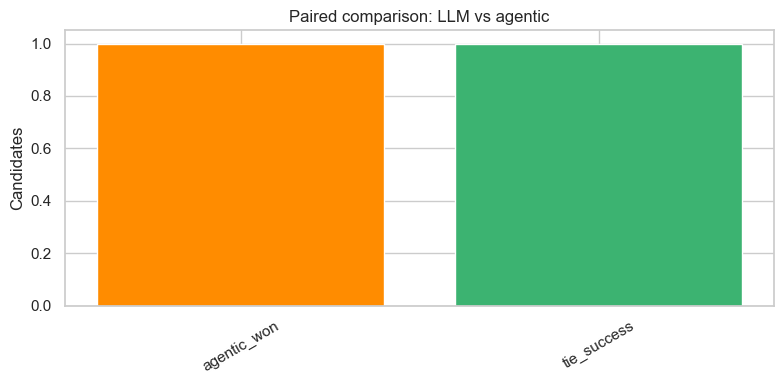

In [2]:
paired = build_paired_comparison(candidates)
print(f'Paired candidate rows: {len(paired)}')
print(paired['winner'].value_counts())

fig, ax = plt.subplots(figsize=(8, 4))
paired_win_loss_matrix(paired, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# McNemar's test on paired candidates where both lanes ran.
# Restrict to rows where both validated_success values are non-NA.
both = paired[
    paired['winner'].isin(['llm_won', 'agentic_won', 'tie_success', 'tie_failure'])
    & paired['llm_validated_success'].notna()
    & paired['agentic_validated_success'].notna()
]
if len(both) >= 5:
    result = mcnemar_test(both['llm_validated_success'], both['agentic_validated_success'])
    print(f"McNemar's: stat={result.statistic:.3f}, p={result.p_value:.4f}, n={result.n}")
    print(f"  odds ratio (llm_wins/agentic_wins) = {result.effect_size:.3f}  [{result.effect_size_label}]")
    print(f"  {result.note}")
else:
    print(f'Too few paired candidates for McNemar test (n={len(both)}, need â‰¥5 discordant pairs).')
    if len(both) > 0:
        print('Descriptive counts only:')
        print(both['winner'].value_counts())


## 3. Repository-Weighted Comparison

Aggregates success and coverage rates at the repository level and compares lanes. When per-repository rows are available, describes the distribution across repositories. Falls back to a **repository-blocked bootstrap** when repository-level summaries are unavailable.

The blocked bootstrap resamples whole repositories (with replacement) rather than individual attempts, which accounts for within-repository correlation â€” attempts from the same codebase share structure, difficulty, and tool configuration. With only 2 repositories, the bootstrap CI has limited coverage but still provides a more honest uncertainty estimate than an attempt-level interval.


In [4]:
if not repos.empty and 'validated_success_rate' in repos.columns:
    display(repos.groupby('lane')[['validated_success_rate', 'mean_coverage_delta', 'mean_mutation_delta']].describe())
else:
    # Fall back to attempt-level repository-blocked bootstrap
    if 'repository_key' in attempts.columns and 'validated_success' in attempts.columns:
        for lane in ('llm', 'agentic'):
            sub = attempts[attempts['lane'] == lane]
            if len(sub) < 2:
                continue
            ci = repository_blocked_bootstrap(sub, lambda df: df['validated_success'].mean())
            print(f"{lane}: success_rate={ci.estimate:.3f} [{ci.lower:.3f}, {ci.upper:.3f}]")

validated_success_rate                                            \
                         count mean       std  min   25%  50%   75%  max   
lane                                                                       
agentic                    2.0  1.0  0.000000  1.0  1.00  1.0  1.00  1.0   
llm                        2.0  0.5  0.707107  0.0  0.25  0.5  0.75  1.0   

        mean_coverage_delta            ...                      \
                      count      mean  ...       75%       max   
lane                                   ...                       
agentic                 2.0  0.423913  ...  0.461957  0.500000   
llm                     2.0  0.170290  ...  0.172101  0.173913   

        mean_mutation_delta                                                    \
                      count      mean       std       min       25%       50%   
lane                                                                            
agentic                 2.0  6.470542  8.526941  0.441084  3.455813  6.470542   
llm                     2.0 -0.031506  0.044556 -0.063012 -0.047259 -0.031506   

                         
              75%   max  
lane                     
agentic  9.485271  12.5  
llm     -0.015753   0.0  

[2 rows x 24 columns]

## 4. Attempt-Weighted Comparison

Treats each attempt as a separate observation and compares success rates and coverage distributions between lanes.

**Limitation:** Multiple attempts on the same candidate are not independent â€” they share the same source method, context, and difficulty. This inflates the effective sample size and deflates p-values. The candidate-weighted sensitivity check in Section 7 is the methodologically preferred estimate for the headline lane comparison; this section should be read as a secondary view.

Mann-Whitney U tests whether coverage deltas from one lane tend to be larger than the other (non-parametric, no normality assumption). Effect size is Cliff's delta âˆˆ [-1, 1]; |Î´| < 0.15 is negligible, 0.15â€“0.33 small, 0.33â€“0.47 medium, > 0.47 large.

VEP rate (tests that passed **and** improved metrics) is reported alongside the broad `validated_success` rate to separate passing tests from impactful tests.


In [ ]:
if 'lane' in attempts.columns and 'validated_success' in attempts.columns:
    table = attempts.groupby('lane')[['validated_success']].agg(['sum', 'count', 'mean'])
    table.columns = ['successes', 'total', 'success_rate']
    # Add VEP rate separately to distinguish passing tests from impactful tests
    if 'validated_evidence_positive' in attempts.columns:
        vep = attempts.groupby('lane')['validated_evidence_positive'].agg(['sum', 'mean'])
        vep.columns = ['vep_count', 'vep_rate']
        table = table.join(vep)
    display(table)

# Mann-Whitney U on coverage_delta (attempt-weighted, not candidate-paired)
if 'lane' in attempts.columns and 'coverage_delta' in attempts.columns:
    llm_d = attempts[attempts['lane'] == 'llm']['coverage_delta'].dropna()
    ag_d  = attempts[attempts['lane'] == 'agentic']['coverage_delta'].dropna()
    if len(llm_d) >= 2 and len(ag_d) >= 2:
        result = mann_whitney_u(llm_d, ag_d)
        print(f"Mann-Whitney U (coverage_delta): stat={result.statistic:.1f}, p={result.p_value:.4f}, n={result.n}")
        print(f"  Cliff's delta = {result.effect_size:.3f}  (>0 = agentic larger; note: attempt-weighted, see Â§7 for candidate-weighted)")


## 5. Cost-Effectiveness

Compares runtime and token usage against coverage improvement to assess efficiency, not just raw success rate. Reports validated successes per minute and per 1k tokens as normalised productivity metrics.


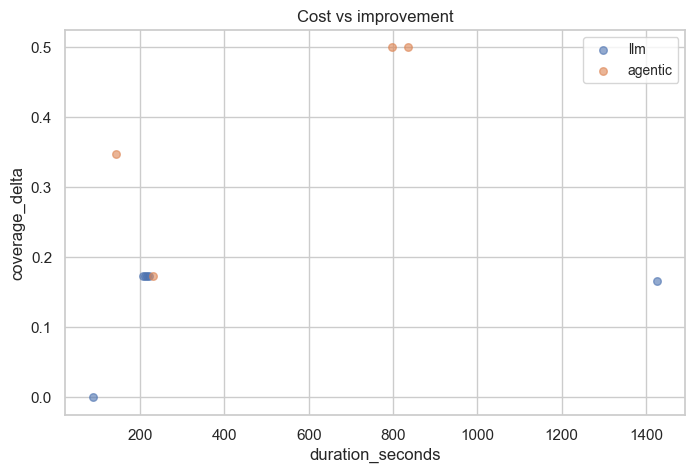

Validated successes per minute:
lane
agentic    0.089854
llm        0.025320
dtype: float64


In [6]:
if all(c in attempts.columns for c in ['duration_seconds', 'coverage_delta', 'lane']):
    fig, ax = plt.subplots(figsize=(8, 5))
    cost_vs_improvement_scatter(attempts, 'duration_seconds', 'coverage_delta', 'lane', ax=ax)
    plt.show()

# Successes per minute
if 'duration_seconds' in attempts.columns and 'validated_success' in attempts.columns:
    spm = attempts.groupby('lane').apply(
        lambda g: g['validated_success'].sum() / (g['duration_seconds'].sum() / 60)
    )
    print('Validated successes per minute:')
    print(spm)

## 6. Risk / Change Footprint

Quantifies what the agentic lane modified beyond the target test file â€” production files changed, project files changed, files deleted. A production-file change rate > 0 is a correctness risk: the tool altered non-test code, which may not be intentional.


In [7]:
agentic = attempts[attempts.get('lane', pd.Series()) == 'agentic']
footprint_cols = [c for c in ['changed_files_count', 'production_files_changed',
                               'project_files_changed', 'deleted_files_count'] if c in agentic.columns]
if footprint_cols:
    display(agentic[footprint_cols].describe().T)

# Production/project file change rate
if 'production_files_changed' in agentic.columns:
    rate = (agentic['production_files_changed'].fillna(0) > 0).mean()
    print(f'Agentic production-file change rate: {rate:.1%}')

,count,mean,std,min,25%,50%,75%,max
changed_files_count,4.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


## 7. Sensitivity Analyses

Re-runs the primary comparison at the candidate level (best attempt per candidate per lane) to check whether the headline finding holds when pseudoreplication is removed. **Candidate-weighted is the methodologically preferred estimate** for the lane comparison; the attempt-weighted rate in Section 4 should be treated as a secondary view.

If attempt-weighted and candidate-weighted rates agree in direction and magnitude, the finding is robust to aggregation choice. If they diverge, the candidate-weighted result should be reported as primary.


In [10]:
# Compare attempt-weighted vs candidate-weighted success rates
print('=== Attempt-weighted ===')
if 'lane' in attempts.columns and 'validated_success' in attempts.columns:
    agg = attempts.groupby('lane')[['validated_success']].mean()
    if 'validated_evidence_positive' in attempts.columns:
        agg['vep_rate'] = attempts.groupby('lane')['validated_evidence_positive'].mean()
    print(agg)

print('\n=== Candidate-weighted (preferred for primary comparison) ===')
if 'lane' in candidates.columns and 'any_validated_success' in candidates.columns:
    cagg = candidates.groupby('lane')[['any_validated_success']].mean()
    if 'validated_evidence_positive_count' in candidates.columns:
        cagg['vep_rate'] = candidates.groupby('lane').apply(
            lambda g: (g['validated_evidence_positive_count'] > 0).mean()
        )
    print(cagg)


=== Attempt-weighted ===
         validated_success
lane                      
agentic           0.750000
llm               0.166667

=== Candidate-weighted (preferred for primary comparison) ===
         any_validated_success
lane                          
agentic                    1.0
llm                        0.5


## 8. Outcome Classification by Lane

Shows the full outcome taxonomy broken down by lane, complementing the binary success rates above. Distinguishes ValidatedEvidencePositive (passed + metrics improved), ValidatedLowImpact (passed + no metric improvement), FailedEvidencePositive (test failed but metrics moved), and various failure modes.


In [11]:
from analysis.plots import outcome_classification_bar

if 'outcome_classification' in attempts.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    outcome_classification_bar(attempts, group_col='lane', ax=ax)
    plt.tight_layout()
    plt.show()

    oc_table = attempts.groupby(['lane', 'outcome_classification']).size().unstack(fill_value=0)
    oc_pct = oc_table.div(oc_table.sum(axis=1), axis=0).mul(100)
    print('Outcome distribution (%):')
    display(oc_pct.round(1))
else:
    print('outcome_classification column not found.')

ImportError: cannot import name 'outcome_classification_bar' from 'analysis.plots' (D:\Projects\TestMap\Analysis\src\analysis\plots.py)

## 9. Code Metrics: Baseline → Generated Test

Compares structural properties of the **baseline tests** against the **generated tests** (cyclomatic complexity, maintainability index, SLOC, coupling) as a slope chart. Each line is one attempt; the mean overlay shows the typical direction of transformation. Note: this section includes all attempts regardless of outcome.


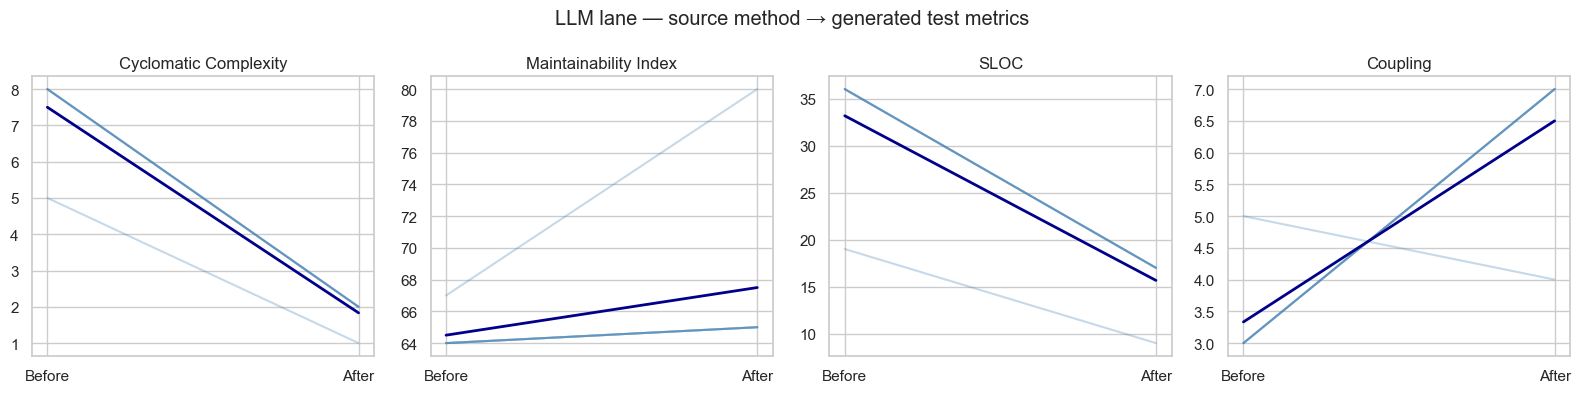

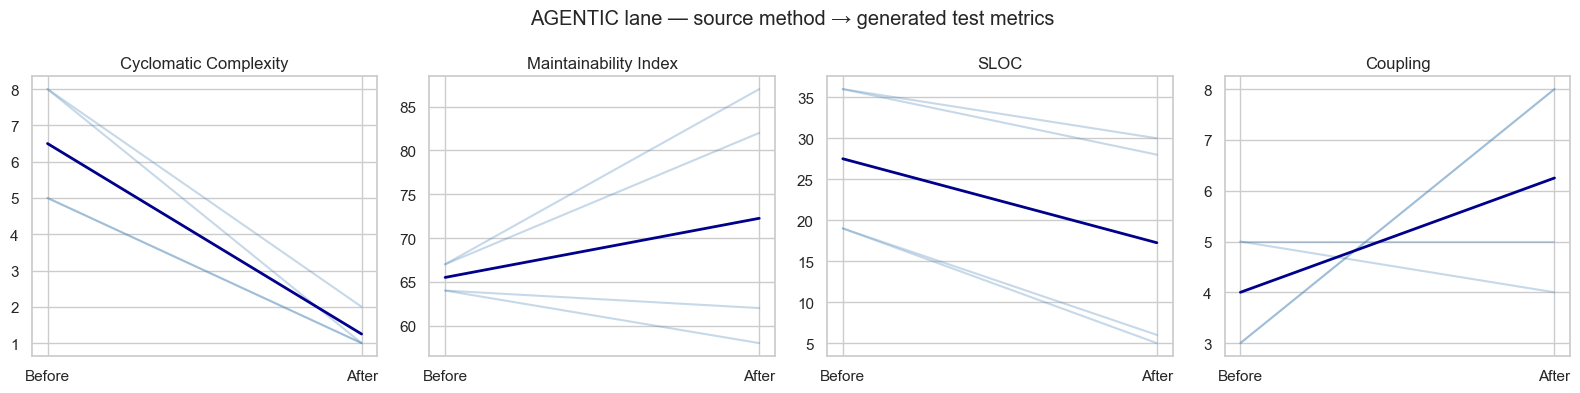


Median metrics by lane:


,source_method_cc,generated_test_cc,source_method_mi,generated_test_mi,source_method_sloc,generated_test_sloc,source_method_coupling,generated_test_coupling
lane,,,,,,,,
agentic,6.5,1.0,65.5,72.0,27.5,17.0,4.0,6.5
llm,8.0,2.0,64.0,65.0,36.0,17.0,3.0,7.0


In [10]:
from analysis.plots import before_after_slope

metric_pairs = [
    ('baseline_test_cc',       'generated_test_cc',       'Cyclomatic Complexity'),
    ('baseline_test_mi',       'generated_test_mi',       'Maintainability Index'),
    ('baseline_test_sloc',     'generated_test_sloc',     'SLOC'),
    ('baseline_test_coupling', 'generated_test_coupling', 'Coupling'),
]
available = [(b, g, lbl) for b, g, lbl in metric_pairs
             if b in attempts.columns and g in attempts.columns]

if available:
    for lane in ('llm', 'agentic'):
        lane_df = attempts[attempts['lane'] == lane]
        if len(lane_df) == 0:
            continue
        fig, axes = plt.subplots(1, len(available), figsize=(4 * len(available), 4))
        if len(available) == 1:
            axes = [axes]
        for ax, (before_col, after_col, label) in zip(axes, available):
            before_after_slope(lane_df, before_col, after_col, ax=ax)
            ax.set_title(f'{label}')
        plt.suptitle(f'{lane.upper()} lane — baseline → generated test metrics')
        plt.tight_layout()
        plt.show()

# Summary table: median by lane
all_metric_cols = [c for pair in available for c in pair[:2] if c in attempts.columns]
if all_metric_cols and 'lane' in attempts.columns:
    print('
Median metrics by lane:')
    display(attempts.groupby('lane')[all_metric_cols].median().round(2))


## 10. Test Smell Comparison: Baseline vs Generated

Counts and categorises test smell instances in the baseline (existing) test class and in the generated test, split by lane. A higher generated smell count relative to baseline suggests the tool is introducing code quality issues alongside the new test.


Baseline smell counts by lane:
         sum  mean  median
lane                      
agentic    0   0.0     0.0
llm        0   0.0     0.0

Generated smell counts by lane:
         sum  mean  median
lane                      
agentic    3  0.75     0.5
llm       10  1.67     2.0



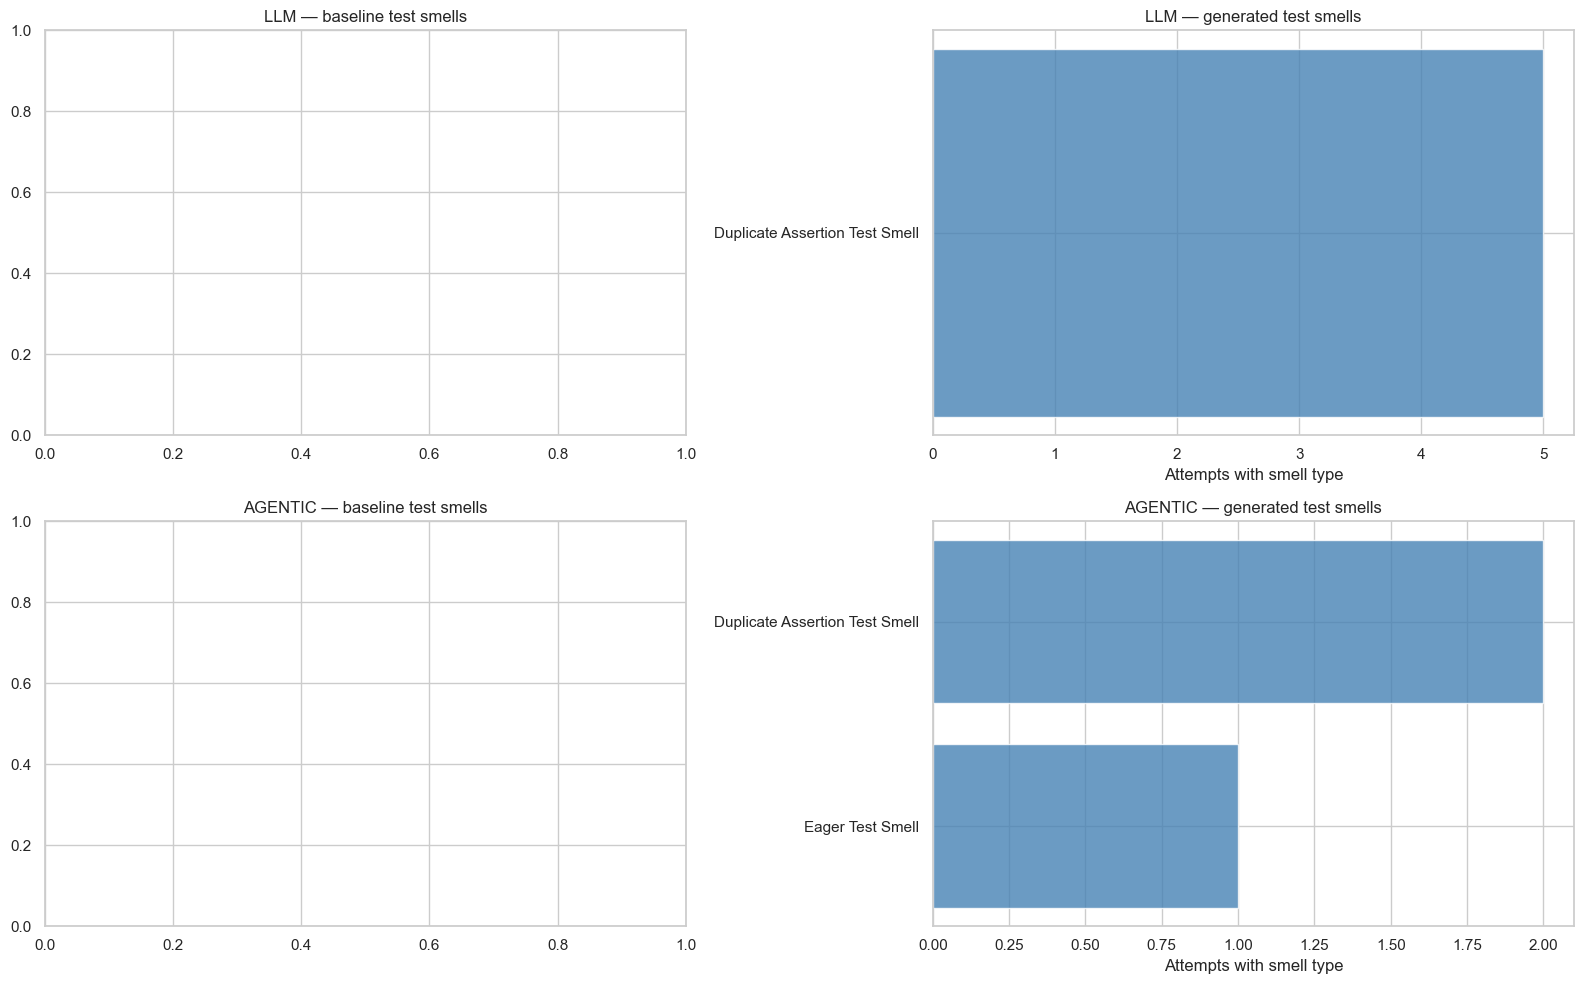

In [11]:
from analysis.plots import smell_type_breakdown

# Smell count summary by lane
for count_col, label in [('baseline_test_smell_count', 'Baseline'), ('generated_test_smell_count', 'Generated')]:
    if count_col in attempts.columns:
        print(f'{label} smell counts by lane:')
        print(attempts.groupby('lane')[count_col].agg(['sum', 'mean', 'median']).round(2))
        print()

# Smell type breakdown by lane
lanes = [l for l in ('llm', 'agentic') if l in attempts['lane'].values]
n_lanes = len(lanes)
if n_lanes > 0:
    fig, axes = plt.subplots(n_lanes, 2, figsize=(16, 5 * n_lanes), squeeze=False)
    for row, lane in enumerate(lanes):
        lane_df = attempts[attempts['lane'] == lane]
        smell_type_breakdown(lane_df, 'baseline_test_smell_types',  ax=axes[row][0])
        axes[row][0].set_title(f'{lane.upper()} â€” baseline test smells')
        smell_type_breakdown(lane_df, 'generated_test_smell_types', ax=axes[row][1])
        axes[row][1].set_title(f'{lane.upper()} â€” generated test smells')
    plt.tight_layout()
    plt.show()

## 11. Timing and Cost by Lane

Median and total duration, generation vs validation phase breakdown, and cost-per-success by lane. Provides the denominator for interpreting success rates: a lane with a higher success rate but 10Ã— the runtime may not be more efficient.


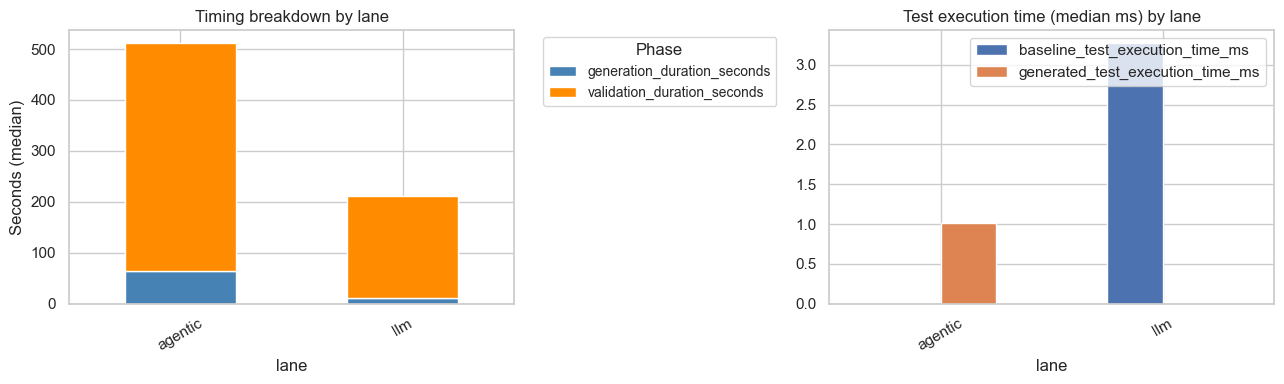


Cost per validated success:


,total_seconds,successes,total_tokens,seconds_per_success,tokens_per_success
lane,,,,,
agentic,2003.2,3.0,630465.0,667.7,210155.0
llm,2369.7,1.0,67715.0,2369.7,67715.0


In [12]:
from analysis.plots import timing_stacked_bar

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
timing_stacked_bar(attempts, group_col='lane', ax=axes[0])

exec_cols = [c for c in ['baseline_test_execution_time_ms', 'generated_test_execution_time_ms']
             if c in attempts.columns]
if exec_cols:
    attempts.groupby('lane')[exec_cols].median().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Test execution time (median ms) by lane')
    axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Cost per success
if all(c in attempts.columns for c in ['duration_seconds', 'validated_success', 'total_tokens']):
    cost_per_success = attempts.groupby('lane').apply(lambda g: pd.Series({
        'total_seconds': g['duration_seconds'].sum(),
        'successes': g['validated_success'].sum(),
        'total_tokens': g['total_tokens'].sum(),
        'seconds_per_success': g['duration_seconds'].sum() / max(g['validated_success'].sum(), 1),
        'tokens_per_success': g['total_tokens'].sum() / max(g['validated_success'].sum(), 1),
    }))
    print('\nCost per validated success:')
    display(cost_per_success.round(1))